# EDA - Phân tích dữ liệu 1000 doanh nghiệp Việt Nam

Phân tích file `company_info_sample_1000.csv` gồm 1000 doanh nghiệp, 24 cột.  
Mục tiêu là hiểu cấu trúc và chất lượng dữ liệu trước khi xây dựng knowledge graph phục vụ bài toán credit scoring.

## 1. Setup – Import thư viện và load dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})
sns.set_style("whitegrid")

df = pd.read_csv("../data/company_info_sample_1000.csv", dtype=str)
print(f"Da load {len(df):,} dong, {df.shape[1]} cot")

Da load 1,000 dong, 24 cot


## 2. Tổng quan dataset

Xem nhanh shape, kiểu dữ liệu, 3 dòng đầu, thông tin cột và bộ nhớ sử dụng.

In [2]:
print("=== SHAPE ===")
print(f"Số dòng: {df.shape[0]:,}  |  Số cột: {df.shape[1]}\n")

print("=== DANH SÁCH CỘT & KIỂU DỮ LIỆU ===")
print(df.dtypes.to_string())

print("\n=== 3 DÒNG ĐẦU ===")
display(df.head(3))

print("\n=== THÔNG TIN TỔNG HỢP (df.info) ===")
df.info(memory_usage="deep")

mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"\n→ Tổng bộ nhớ sử dụng: {mem_mb:.2f} MB")

=== SHAPE ===
Số dòng: 1,000  |  Số cột: 24

=== DANH SÁCH CỘT & KIỂU DỮ LIỆU ===
id                                      object
tax_code                                object
tax_address                             object
abbreviated_name                        object
name                                    object
company_link_id                         object
html_location                           object
international_name                      object
legal_main_business_profession_href     object
legal_main_business_profession_title    object
legal_issue_date_title                  object
legal_issue_date_text                   object
legal_href                              object
legal_issue_date_href                   object
legal_main_business_profession_text     object
legal_status                            object
business_professions                    object
updated_time                            object
new_address                             object
new_address_ward         

,id,tax_code,tax_address,abbreviated_name,name,company_link_id,html_location,international_name,legal_main_business_profession_href,legal_main_business_profession_title,...,legal_main_business_profession_text,legal_status,business_professions,updated_time,new_address,new_address_ward,new_address_province,is_new_address_null,is_new_address_ward_null,process_address_status
0,1,0402149708,"32 Phan Bội Châu, Phường Thạch Thang, Quận Hải...",NaN,CÔNG TY TNHH THƯƠNG MẠI DU LỊCH HIẾU NHUNG,5,NaN,NaN,industry-7912/dieu-hanh-tua-du-lich,Điều hành tua du lịch,...,Điều hành tua du lịch,Đang hoạt động,"[{""id"":""5629"",""href"":""industry-5629/dich-vu-an...",2022-05-23,"32 Phan Bội Châu, Phường Hải Châu, Thành...",Phường Hải Châu,Thành phố Đà Nẵng,0,0,2
1,2,0317305554,"Số 07 Đường Số 04, Cityland Park Hills, Phường...",NaN,CÔNG TY TNHH SẢN XUẤT THƯƠNG MẠI DỊCH VỤ TUỆ T...,6,NaN,NaN,industry-4799/ban-le-hinh-thuc-khac-chua-duoc-...,Bán lẻ hình thức khác chưa được phân vào đâu,...,Bán lẻ hình thức khác chưa được phân vào đâu,Đang hoạt động (đã được cấp GCN ĐKT),"[{""id"":""4293"",""href"":""industry-4293/xay-dung-c...",2022-05-23,"Số 07 Đường Số 04 Cityland Park Hills, Phườ...",Phường Gò Vấp,Thành phố Hồ Chí Minh,0,0,2
2,3,0317300193,"Số A3, 255/1 Khu phố 7, Phường Thới An, Quận ...",NaN,CÔNG TY TNHH SX TM TRIỀU ĐẠI PHÁT,7,NaN,NaN,industry-2511/san-xuat-cac-cau-kien-kim-loai,Sản xuất các cấu kiện kim loại,...,Sản xuất các cấu kiện kim loại,Đang hoạt động,"[{""id"":""2593"",""href"":""industry-2593/san-xuat-d...",2022-05-23,"Số A3 255/1 Khu phố 7, Phường Thới An, Th...",Phường Thới An,Thành phố Hồ Chí Minh,0,0,2



=== THÔNG TIN TỔNG HỢP (df.info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   id                                    1000 non-null   object
 1   tax_code                              1000 non-null   object
 2   tax_address                           1000 non-null   object
 3   abbreviated_name                      503 non-null    object
 4   name                                  1000 non-null   object
 5   company_link_id                       1000 non-null   object
 6   html_location                         0 non-null      object
 7   international_name                    464 non-null    object
 8   legal_main_business_profession_href   866 non-null    object
 9   legal_main_business_profession_title  866 non-null    object
 10  legal_issue_date_title                981 non-null    objec

## 3. Giá trị thiếu (Missing Values)

Tính tỷ lệ null từng cột, sắp xếp giảm dần và vẽ biểu đồ để xác định cột nào có vấn đề.

,Cột,Số thiếu,% thiếu
0,html_location,1000,100.000000
1,international_name,536,53.600000
2,abbreviated_name,497,49.700000
3,legal_status,216,21.600000
4,legal_main_business_profession_href,134,13.400000
5,legal_main_business_profession_text,134,13.400000
6,legal_main_business_profession_title,134,13.400000
7,updated_time,49,4.900000
8,legal_issue_date_href,19,1.900000
9,legal_issue_date_title,19,1.900000


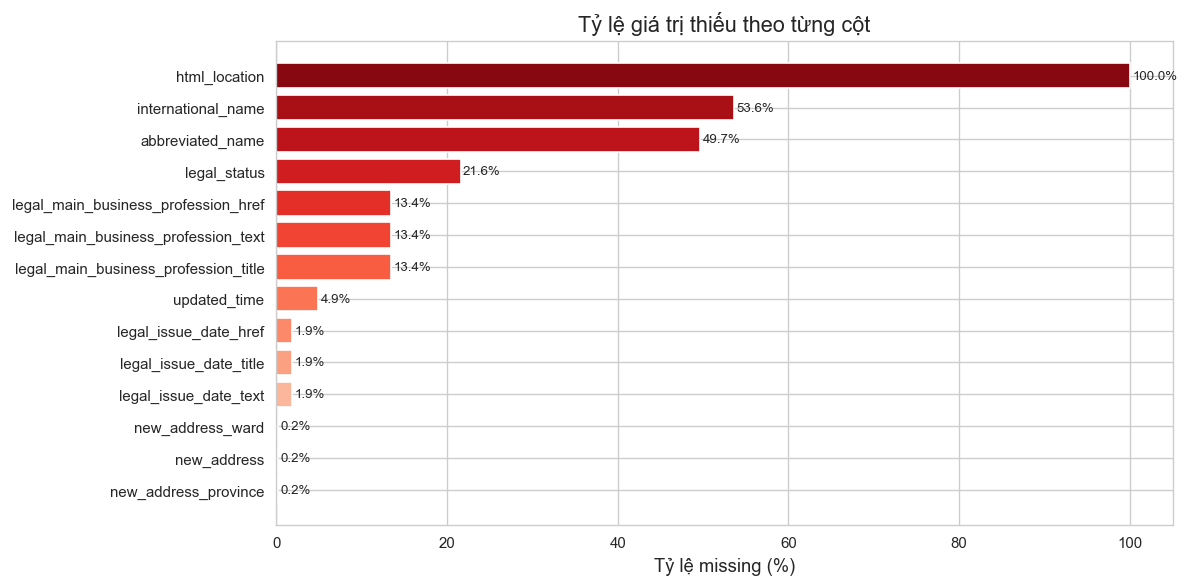

In [3]:
# Tính missing
missing = pd.DataFrame({
    "Cột": df.columns,
    "Số thiếu": df.isna().sum().values,
    "% thiếu": (df.isna().mean() * 100).round(2).values,
}).sort_values("% thiếu", ascending=False).reset_index(drop=True)

display(missing.style.background_gradient(subset=["% thiếu"], cmap="Reds"))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
cols_with_missing = missing[missing["% thiếu"] > 0]
bars = ax.barh(
    cols_with_missing["Cột"],
    cols_with_missing["% thiếu"],
    color=sns.color_palette("Reds_r", len(cols_with_missing))
)
ax.set_xlabel("Tỷ lệ missing (%)")
ax.set_title("Tỷ lệ giá trị thiếu theo từng cột")
ax.invert_yaxis()
for bar, val in zip(bars, cols_with_missing["% thiếu"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

## 4. Phân tích theo nhóm cột

### 4.1 Nhóm định danh: `tax_code`, `name`, `abbreviated_name`, `international_name`

Kiểm tra tính duy nhất của mã số thuế và độ đầy đủ các trường tên.

Kết quả: `tax_code` có 1000/1000 giá trị unique, không trùng lặp - phù hợp làm khóa chính cho node Company. Tuy nhiên 134 mã có dạng `XXXXXXXXXX-XXX` (ví dụ `0401799005-003`) là mã chi nhánh, không phải pháp nhân độc lập, cần xử lý riêng khi build graph. `abbreviated_name` thiếu 49.7% và `international_name` thiếu 53.6%, chỉ dùng được làm thuộc tính phụ.

Kiem tra tinh duy nhat
  tax_code                  | tong: 1000 | unique: 1000 | trung lap:   0
  name                      | tong: 1000 | unique:  999 | trung lap:   1
  abbreviated_name          | tong:  503 | unique:  503 | trung lap:   0
  international_name        | tong:  464 | unique:  464 | trung lap:   0

Kiem tra tax_code hop le (10 chu so)
  Hop le 10 so: 866 / 1000
  Mau khong hop le (chi nhanh):
5     0401799005-003
11    2500571196-003
29    8756796665-001
55    3301641299-001
67    2100234326-010


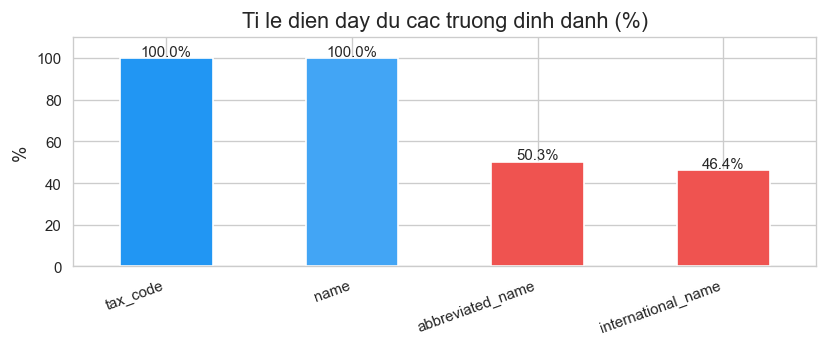

In [4]:
id_cols = ["tax_code", "name", "abbreviated_name", "international_name"]

print("Kiem tra tinh duy nhat")
for col in id_cols:
    total = df[col].notna().sum()
    unique = df[col].nunique()
    dup = total - unique
    print(f"  {col:<25} | tong: {total:>4} | unique: {unique:>4} | trung lap: {dup:>3}")

print("\nKiem tra tax_code hop le (10 chu so)")
valid_mask = df["tax_code"].str.match(r"^\d{10}$", na=False)
print(f"  Hop le 10 so: {valid_mask.sum()} / {df['tax_code'].notna().sum()}")
print(f"  Mau khong hop le (chi nhanh):\n{df.loc[~valid_mask, 'tax_code'].head(5).to_string()}")

fig, ax = plt.subplots(figsize=(7, 3))
fill_rate = df[id_cols].notna().mean() * 100
fill_rate.plot(kind="bar", ax=ax, color=["#2196F3", "#42A5F5", "#EF5350", "#EF5350"], edgecolor="white")
ax.set_title("Ti le dien day du cac truong dinh danh (%)")
ax.set_ylabel("%")
ax.set_ylim(0, 110)
ax.set_xticklabels(id_cols, rotation=20, ha="right")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### 4.2 Nhóm pháp lý: `legal_status`, `legal_issue_date_text`

Xem phân bố trạng thái pháp lý và phân phối ngày thành lập.

Kết quả: `legal_status` thiếu 21.6% (216 dòng null). Cùng ý nghĩa "đang hoạt động" nhưng có 4 cách viết khác nhau ("Đang hoạt động", "Đang Hoạt Động", "NNT đang hoạt động...", v.v.) - cần chuẩn hóa trước khi dùng làm feature. Chỉ có 6 công ty ở trạng thái inactive. Ngày thành lập trải từ 1984 đến 2022, đa số tập trung năm 2022 - đây là lý do hầu hết công ty đều đang hoạt động.

,Trang thai,So luong,%
0,Đang hoạt động,377,37.7
1,Đang hoạt động (đã được cấp GCN ĐKT),316,31.6
2,NaN,216,21.6
3,NNT đang hoạt động (đã được cấp GCN ĐKT),67,6.7
4,Đang Hoạt Động,14,1.4
5,Đang hoạt động (được cấp thông báo MST),4,0.4
6,Ngừng hoạt động nhưng chưa hoàn thành thủ tục ...,3,0.3
7,Ngừng hoạt động và đã đóng MST,1,0.1
8,Không hoạt động tại địa chỉ đã đăng ký,1,0.1
9,Tạm nghỉ kinh doanh có thời hạn,1,0.1


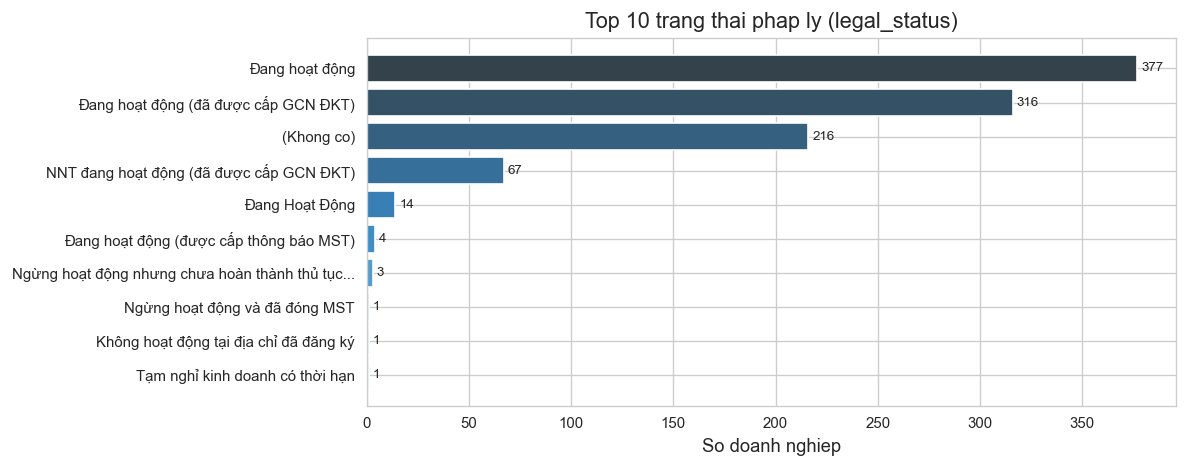


Phan bo ngay thanh lap (legal_issue_date_text)
  Parse duoc: 981 / 1000
  Som nhat: 1984-10-25  |  Muon nhat: 2022-06-22


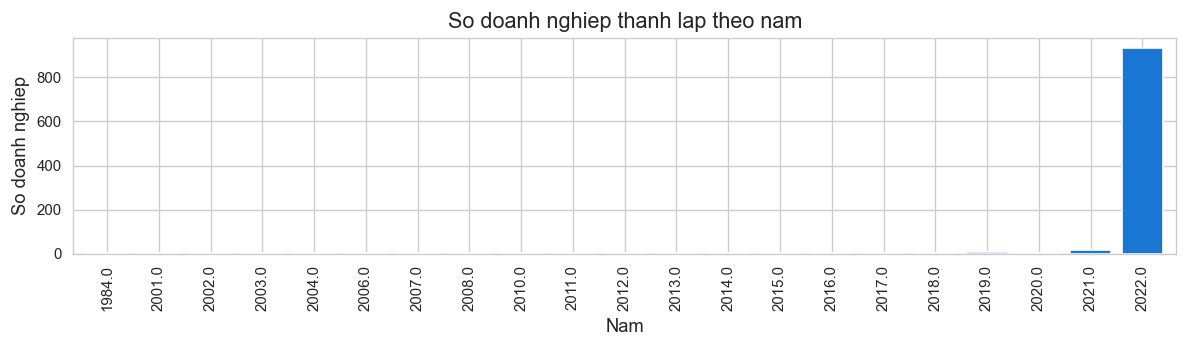

In [5]:
status_counts = df["legal_status"].value_counts(dropna=False).reset_index()
status_counts.columns = ["Trang thai", "So luong"]
status_counts["%"] = (status_counts["So luong"] / len(df) * 100).round(2)
display(status_counts)

fig, ax = plt.subplots(figsize=(10, 4))
top_status = df["legal_status"].fillna("(Khong co)").value_counts().head(10)
labels = [s[:45] + "..." if len(s) > 45 else s for s in top_status.index]
ax.barh(labels[::-1], top_status.values[::-1],
        color=sns.color_palette("Blues_d", len(top_status)))
ax.set_xlabel("So doanh nghiep")
ax.set_title("Top 10 trang thai phap ly (legal_status)")
for bar, val in zip(ax.patches, top_status.values[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=8)
plt.tight_layout()
plt.show()

print("\nPhan bo ngay thanh lap (legal_issue_date_text)")
date_parsed = pd.to_datetime(df["legal_issue_date_text"], dayfirst=True, errors="coerce")
print(f"  Parse duoc: {date_parsed.notna().sum()} / {len(df)}")
print(f"  Som nhat: {date_parsed.min().date()}  |  Muon nhat: {date_parsed.max().date()}")

fig, ax = plt.subplots(figsize=(10, 3))
date_parsed.dt.year.value_counts().sort_index().plot(kind="bar", ax=ax, color="#1976D2", width=0.8)
ax.set_title("So doanh nghiep thanh lap theo nam")
ax.set_xlabel("Nam")
ax.set_ylabel("So doanh nghiep")
plt.tight_layout()
plt.show()

### 4.3 Ngành nghề: `business_professions`

Cột chứa JSON array danh sách ngành đăng ký. Ta parse để đếm số ngành mỗi công ty và tìm top 20 ngành phổ biến nhất.

Kết quả: Có 430 ngành unique trong toàn dataset. Trung bình 21.2 ngành/công ty (trung vị 14, tối đa 220). Phân phối lệch phải khá mạnh. 132 công ty parse ra 0 ngành, cần kiểm tra lại. Cạnh Company-Industry sẽ là loại cạnh nhiều nhất trong graph (~21,158 cạnh, chiếm 84% tổng).

Thong ke so nganh dang ky / doanh nghiep
count    1000.00
mean       21.16
std        23.25
min         0.00
25%         4.00
50%        14.00
75%        30.00
max       220.00
Name: prof_count, dtype: float64

  Trung binh : 21.2 nganh
  Trung vi   : 14 nganh
  Toi da     : 220 nganh
  Cong ty 0 nganh: 132


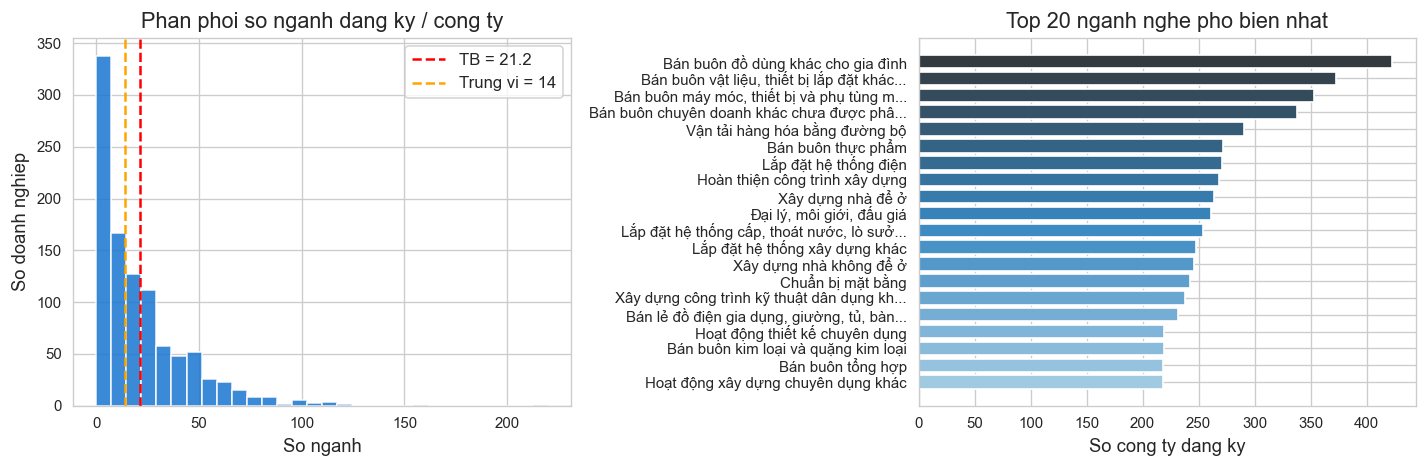


Tong so nganh unique: 430


In [6]:
def parse_professions(s):
    # Parse JSON, loc trung theo id, tra ve list ten nganh
    try:
        items = json.loads(s)
        seen = set()
        result = []
        for item in items:
            if item.get("id") not in seen:
                seen.add(item.get("id"))
                result.append(item.get("title", ""))
        return result
    except Exception:
        return []

df["prof_list"] = df["business_professions"].apply(parse_professions)
df["prof_count"] = df["prof_list"].apply(len)

print("Thong ke so nganh dang ky / doanh nghiep")
print(df["prof_count"].describe().round(2))
print(f"\n  Trung binh : {df['prof_count'].mean():.1f} nganh")
print(f"  Trung vi   : {df['prof_count'].median():.0f} nganh")
print(f"  Toi da     : {df['prof_count'].max()} nganh")
print(f"  Cong ty 0 nganh: {(df['prof_count'] == 0).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["prof_count"], bins=30, color="#1976D2", edgecolor="white", alpha=0.85)
axes[0].axvline(df["prof_count"].mean(), color="red", linestyle="--",
                label=f"TB = {df['prof_count'].mean():.1f}")
axes[0].axvline(df["prof_count"].median(), color="orange", linestyle="--",
                label=f"Trung vi = {df['prof_count'].median():.0f}")
axes[0].set_title("Phan phoi so nganh dang ky / cong ty")
axes[0].set_xlabel("So nganh")
axes[0].set_ylabel("So doanh nghiep")
axes[0].legend()

from collections import Counter
all_profs = [p for lst in df["prof_list"] for p in lst if p]
top20 = Counter(all_profs).most_common(20)
labels_20 = [t[0][:40] + "..." if len(t[0]) > 40 else t[0] for t in top20]
values_20 = [t[1] for t in top20]

axes[1].barh(labels_20[::-1], values_20[::-1], color=sns.color_palette("Blues_d", 20))
axes[1].set_title("Top 20 nganh nghe pho bien nhat")
axes[1].set_xlabel("So cong ty dang ky")

plt.tight_layout()
plt.show()

print(f"\nTong so nganh unique: {len(set(all_profs))}")

### 4.4 Địa chỉ: `new_address_province`, `new_address_ward`, `new_address`

Xem phân bố tỉnh/thành và phường/xã, tìm địa chỉ dùng chung giữa nhiều công ty.

Kết quả: 998/1000 công ty có địa chỉ đầy đủ (chỉ 2 null). Chỉ 6 trong 985 địa chỉ unique được chia sẻ bởi từ 2 công ty trở lên (liên quan 19 công ty) - tín hiệu từ Address node khá yếu. Đáng chú ý là cụm "Chợ Mè, Phường Phong Châu, Phú Thọ" có 6 công ty cùng địa chỉ, nhiều khả năng là khu chợ/công nghiệp tập trung.

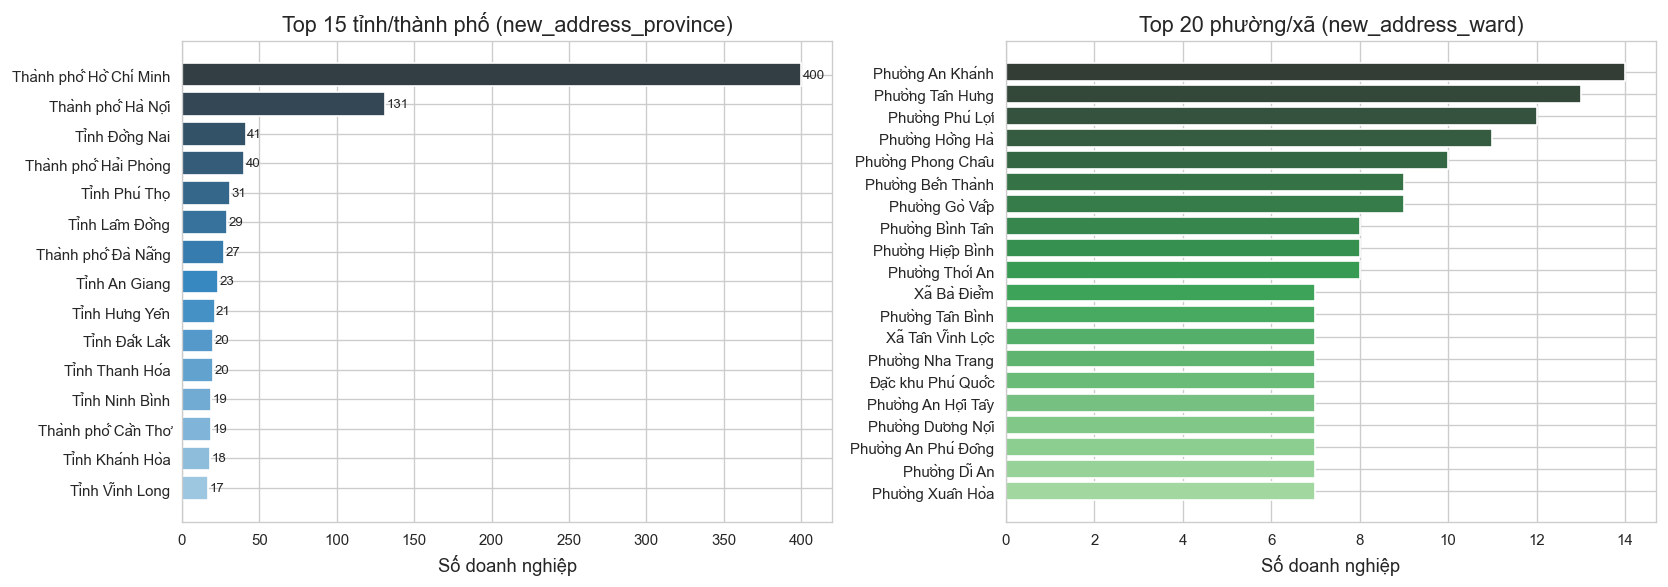


── Địa chỉ dùng chung (≥ 2 công ty) ──
  Tổng địa chỉ unique: 985
  Địa chỉ có ≥2 công ty: 6  (0.6% địa chỉ)
  Số công ty dùng địa chỉ chung: 19

  Top 10 địa chỉ dùng chung nhiều nhất:


,Địa chỉ (chuẩn hóa),Số công ty
0,"chợ mè phú thọ, phường phong châu, tỉnh p...",6
1,"nhà a3, phường phong châu, tỉnh phú thọ",4
2,"số 07 đường số 04 cityland park hills, phườ...",3
3,l17-11 tầng 17 tòa nhà vincom center 72 lê thá...,2
4,"thôn 9, xã xuân du, tỉnh thanh hóa",2
5,"số 6 đường 52, phường an khánh, thành pho...",2


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 15 tỉnh/thành phố
top_province = df["new_address_province"].value_counts().head(15)
axes[0].barh(top_province.index[::-1], top_province.values[::-1],
             color=sns.color_palette("Blues_d", 15))
axes[0].set_title("Top 15 tỉnh/thành phố (new_address_province)")
axes[0].set_xlabel("Số doanh nghiệp")
for bar, val in zip(axes[0].patches, top_province.values[::-1]):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                 str(val), va="center", fontsize=8)

# Top 20 phường/xã
top_ward = df["new_address_ward"].value_counts().head(20)
labels_ward = [w[:30] + "…" if len(w) > 30 else w for w in top_ward.index]
axes[1].barh(labels_ward[::-1], top_ward.values[::-1],
             color=sns.color_palette("Greens_d", 20))
axes[1].set_title("Top 20 phường/xã (new_address_ward)")
axes[1].set_xlabel("Số doanh nghiệp")

plt.tight_layout()
plt.show()

# Địa chỉ dùng chung (≥ 2 công ty) – chuẩn hóa địa chỉ trước
addr_norm = df["new_address"].str.strip().str.lower()
addr_counts = addr_norm.value_counts()
shared_addr = addr_counts[addr_counts >= 2]
print(f"\n── Địa chỉ dùng chung (≥ 2 công ty) ──")
print(f"  Tổng địa chỉ unique: {addr_counts.shape[0]:,}")
print(f"  Địa chỉ có ≥2 công ty: {shared_addr.shape[0]:,}  "
      f"({shared_addr.shape[0]/addr_counts.shape[0]*100:.1f}% địa chỉ)")
print(f"  Số công ty dùng địa chỉ chung: {shared_addr.sum():,}")
print("\n  Top 10 địa chỉ dùng chung nhiều nhất:")
display(shared_addr.head(10).rename("Số công ty").reset_index().rename(
    columns={"new_address": "Địa chỉ (chuẩn hóa)"}))

### 4.5 Nhóm metadata

Các cột kỹ thuật, không phân tích sâu vì không liên quan trực tiếp đến graph:

| Cột | Mô tả | Ghi chú |
|---|---|---|
| `id` | ID nội bộ của record | Dùng làm index |
| `company_link_id` | ID liên kết hệ thống nguồn | |
| `html_location` | Vị trí HTML trang web nguồn | 100% null - loại bỏ |
| `updated_time` | Thời gian cập nhật record | Thiếu 4.9% |
| `is_new_address_null` | Flag địa chỉ null | |
| `is_new_address_ward_null` | Flag phường null | |
| `process_address_status` | Trạng thái xử lý địa chỉ | |

## 5. Người đại diện pháp luật

Cột `legal_href` có dạng URL `search?key=TEN_NGUOI&opt=1`. Ta dùng regex lấy tên, chuẩn hóa (upper + strip), rồi tìm người đại diện cho nhiều công ty vì đây là cạnh quan trọng trong graph.

Kết quả: 100% công ty có thông tin người đại diện (0 null). Có 970 người unique trong 1000 công ty. 21 người đại diện cho từ 2 công ty trở lên, liên quan 51 công ty.

Lưu ý quan trọng: phần lớn trường hợp đại diện nhiều công ty thực ra là chi nhánh cùng tập đoàn (ví dụ LÊ TÙNG đại diện 8 chi nhánh NIN SING LOGISTICS, LÊ VĂN ÚT LỚN đại diện 3 chi nhánh MNS FEED) - đây là cơ cấu tổ chức bình thường, không phải tín hiệu bất thường. Cần lọc chi nhánh (tax_code dạng `XXX-XXX`) trước khi dùng pattern này làm fraud signal.

Thong ke nguoi dai dien phap luat
  Co thong tin nguoi dai dien: 1,000
  So nguoi unique             : 970
  Thieu thong tin             : 0

  Nguoi dai dien >= 2 cong ty: 21
  So cong ty lien quan       : 51

Top 10 nguoi dai dien nhieu cong ty nhat

  [8 cty] LÊ TÙNG
    -> CHI NHÁNH LẠNG SƠN - CÔNG TY TNHH NIN SING LOGISTI; CHI NHÁNH NINH BÌNH - CÔNG TY TNHH NIN SING LOGIST; CHI NHÁNH VĨNH PHÚC - CÔNG TY TNHH NIN SING LOGIST; CHI NHÁNH THÁI NGUYÊN - CÔNG TY TNHH NIN SING LOGI; CHI NHÁNH QUẢNG NINH - CÔNG TY TNHH NIN SING LOGIS; CHI NHÁNH LÀO CAI - CÔNG TY TNHH NIN SING LOGISTIC; CHI NHÁNH LAI CHÂU - CÔNG TY TNHH NIN SING LOGISTI; CHI NHÁNH QUẢNG BÌNH - CÔNG TY TNHH NIN SING LOGIS

  [3 cty] HOÀNG VĂN MẠNH
    -> CÔNG TY TRÁCH NHIỆM HỮU HẠN MỘT THÀNH VIÊN NHUNG T; CÔNG TY TNHH WATERWORLD PHÚ QUỐC; CÔNG TY CỔ PHẦN NÔNG NGHIỆP MINH ĐẠT

  [3 cty] LÊ VĂN ÚT LỚN
    -> CÔNG TY CỔ PHẦN MNS FEED - CHI NHÁNH VĨNH LONG; CÔNG TY CỔ PHẦN MNS FEED - CHI NHÁNH THÁI NGUYÊN; CÔNG TY CỔ PHẦN MNS F

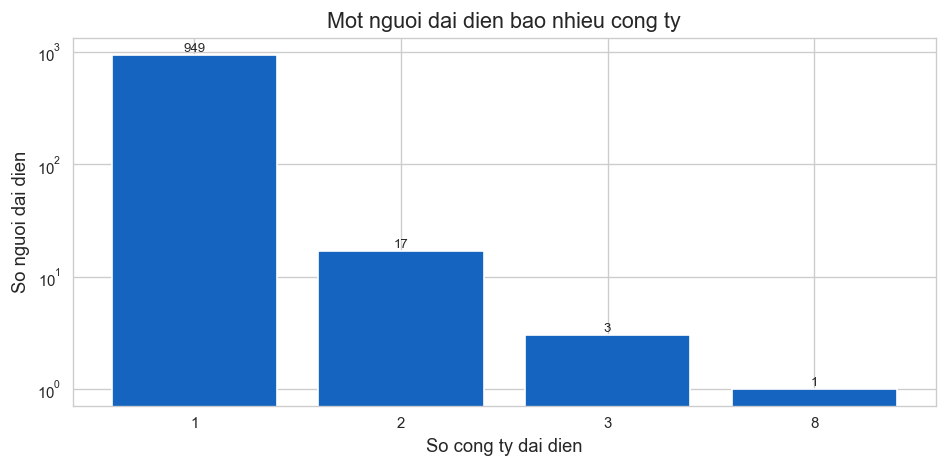

In [8]:
def extract_rep(href):
    # Lay ten nguoi dai dien tu URL, chuan hoa thanh chu hoa
    if pd.isna(href):
        return None
    m = re.search(r"key=([^&]+)", str(href))
    if m:
        return m.group(1).strip().upper()
    return None

df["legal_rep"] = df["legal_href"].apply(extract_rep)

total_reps = df["legal_rep"].notna().sum()
unique_reps = df["legal_rep"].nunique()
print(f"Thong ke nguoi dai dien phap luat")
print(f"  Co thong tin nguoi dai dien: {total_reps:,}")
print(f"  So nguoi unique             : {unique_reps:,}")
print(f"  Thieu thong tin             : {df['legal_rep'].isna().sum()}")

rep_counts = df["legal_rep"].value_counts()
multi_reps = rep_counts[rep_counts >= 2]
print(f"\n  Nguoi dai dien >= 2 cong ty: {len(multi_reps):,}")
print(f"  So cong ty lien quan       : {multi_reps.sum():,}")

print("\nTop 10 nguoi dai dien nhieu cong ty nhat")
for rep_name, count in multi_reps.head(10).items():
    companies = df.loc[df["legal_rep"] == rep_name, "name"].tolist()
    company_list = "; ".join([c[:50] if c else "(N/A)" for c in companies])
    print(f"\n  [{count} cty] {rep_name}")
    print(f"    -> {company_list}")

fig, ax = plt.subplots(figsize=(8, 4))
rep_dist = rep_counts.value_counts().sort_index()
ax.bar(rep_dist.index.astype(str), rep_dist.values, color="#1565C0", edgecolor="white")
ax.set_title("Mot nguoi dai dien bao nhieu cong ty")
ax.set_xlabel("So cong ty dai dien")
ax.set_ylabel("So nguoi dai dien")
ax.set_yscale("log")
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

## 6. Proxy label: trạng thái hoạt động

Vì không có nhãn tín dụng thực tế, ta tạo proxy label từ `legal_status`:
- active: đang hoạt động
- inactive: ngừng / đóng / tạm ngừng / không hoạt động
- unknown: null

Kết quả: active 778 (77.8%), unknown 216 (21.6%), inactive 6 (0.6%). Tỷ lệ active/inactive là 129.7:1 - mất cân bằng rất nặng. Với chỉ 6 mẫu inactive, proxy label này không thể dùng để train model trực tiếp. Nguyên nhân là sample tập trung vào doanh nghiệp mới đăng ký năm 2022, chưa có lịch sử ngừng hoạt động.

Phan phoi proxy label
  active    :  778  (77.8%)
  unknown   :  216  (21.6%)
  inactive  :    6  (0.6%)


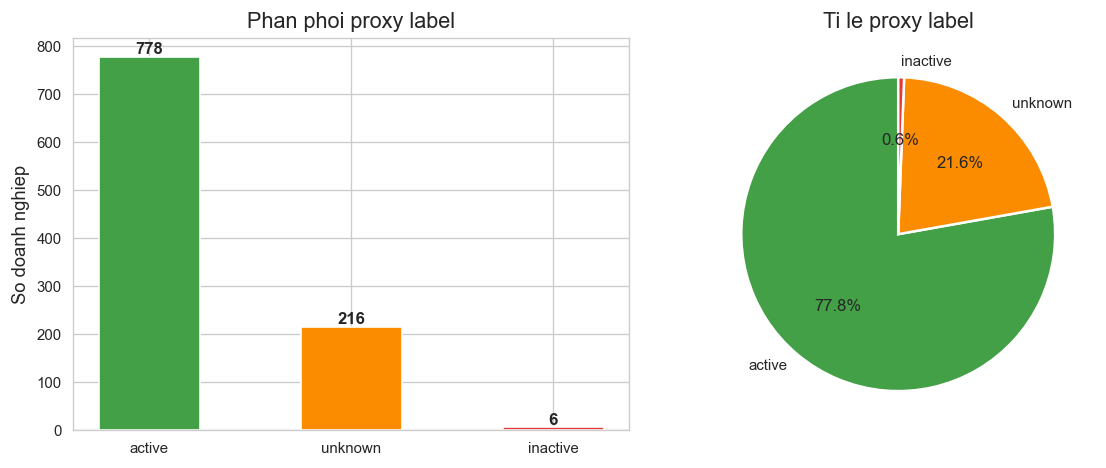


Ti le active/inactive = 129.7:1 -- mat can bang rat nang.
Can them label tu nguon ngoai truoc khi train model.


In [9]:
INACTIVE_KEYWORDS = ["ngừng", "đóng", "tạm", "không hoạt động", "giải thể", "phá sản"]

def normalize_status(s):
    if pd.isna(s):
        return "unknown"
    s_lower = s.lower()
    if any(kw in s_lower for kw in INACTIVE_KEYWORDS):
        return "inactive"
    if "hoạt động" in s_lower or "đang" in s_lower:
        return "active"
    return "unknown"

df["label"] = df["legal_status"].apply(normalize_status)

label_counts = df["label"].value_counts()
label_pct = (label_counts / len(df) * 100).round(2)

print("Phan phoi proxy label")
for lbl in label_counts.index:
    print(f"  {lbl:<10}: {label_counts[lbl]:>4}  ({label_pct[lbl]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colors_map = {"active": "#43A047", "inactive": "#E53935", "unknown": "#FB8C00"}
colors = [colors_map.get(l, "#999") for l in label_counts.index]

axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Phan phoi proxy label")
axes[0].set_ylabel("So doanh nghiep")
for p, val in zip(axes[0].patches, label_counts.values):
    axes[0].text(p.get_x() + p.get_width() / 2, p.get_height() + 5, str(val),
                 ha="center", fontsize=10, fontweight="bold")

axes[1].pie(label_counts.values, labels=label_counts.index,
            colors=colors, autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Ti le proxy label")

plt.tight_layout()
plt.show()

ratio = label_counts.get("active", 0) / max(label_counts.get("inactive", 1), 1)
print(f"\nTi le active/inactive = {ratio:.1f}:1 -- mat can bang rat nang.")
print("Can them label tu nguon ngoai truoc khi train model.")

## 7. Đánh giá khả năng build graph

Tổng hợp 6 loại node có thể xây dựng từ dữ liệu hiện có, kèm số lượng thực tế và mức độ kết nối.

Số liệu thực tế: 1000 Company, 970 Person, 430 Industry, 33 Province, 489 Ward, 985 Address. Tổng cạnh ước tính khoảng 25,152, trong đó Company-Industry chiếm 84% (21,158 cạnh).

In [10]:
n_company  = len(df)
n_person   = df["legal_rep"].nunique()
n_industry = len(set(all_profs))
n_province = df["new_address_province"].nunique()
n_ward     = df["new_address_ward"].nunique()
n_address  = df["new_address"].str.strip().str.lower().nunique()

n_shared_addr  = (df["new_address"].str.strip().str.lower().value_counts().gt(1).sum())
n_multi_person = len(rep_counts[rep_counts >= 2])

graph_summary = pd.DataFrame({
    "Loai Node": [
        "Company", "Person (Dai dien PL)", "Industry (Nganh)",
        "Province (Tinh/TP)", "Ward (Phuong/Xa)", "Address (Dia chi)"
    ],
    "So luong": [n_company, n_person, n_industry, n_province, n_ward, n_address],
    "Loai canh": [
        "-> Person, Industry, Province, Ward, Address",
        "Company -[DAI DIEN]-> Person",
        "Company -[DANG KY NGANH]-> Industry",
        "Company -[TAI]-> Province",
        "Company -[TAI]-> Ward",
        "Company -[CO DIA CHI]-> Address",
    ],
    "Do giau ket noi": ["*****", "****", "*****", "**", "***", "****"],
    "Ghi chu": [
        f"{n_company} cong ty, goc cua graph",
        f"{n_person} nguoi unique; {n_multi_person} dai dien >= 2 cty",
        f"{n_industry} nganh; TB {df['prof_count'].mean():.1f} nganh/cty",
        f"{n_province} tinh/TP -- granularity thap",
        f"{n_ward} phuong/xa -- tot hon province",
        f"{n_shared_addr} dia chi shared >= 2 cty",
    ]
})

display(graph_summary)

print(f"\nUoc tinh tong so canh trong graph:")
print(f"  Company-Person  : ~{n_company} canh")
print(f"  Company-Industry: ~{int(df['prof_count'].sum())} canh")
print(f"  Company-Province: ~{df['new_address_province'].notna().sum()} canh")
print(f"  Company-Ward    : ~{df['new_address_ward'].notna().sum()} canh")
print(f"  Company-Address : ~{df['new_address'].notna().sum()} canh")
total_edges = (n_company + int(df["prof_count"].sum()) +
               df["new_address_province"].notna().sum() +
               df["new_address_ward"].notna().sum() +
               df["new_address"].notna().sum())
print(f"\n  Tong uoc tinh: ~{total_edges:,} canh")

,Loai Node,So luong,Loai canh,Do giau ket noi,Ghi chu
0,Company,1000,"-> Person, Industry, Province, Ward, Address",*****,"1000 cong ty, goc cua graph"
1,Person (Dai dien PL),970,Company -[DAI DIEN]-> Person,****,970 nguoi unique; 21 dai dien >= 2 cty
2,Industry (Nganh),430,Company -[DANG KY NGANH]-> Industry,*****,430 nganh; TB 21.2 nganh/cty
3,Province (Tinh/TP),33,Company -[TAI]-> Province,**,33 tinh/TP -- granularity thap
4,Ward (Phuong/Xa),489,Company -[TAI]-> Ward,***,489 phuong/xa -- tot hon province
5,Address (Dia chi),985,Company -[CO DIA CHI]-> Address,****,6 dia chi shared >= 2 cty



Uoc tinh tong so canh trong graph:
  Company-Person  : ~1000 canh
  Company-Industry: ~21158 canh
  Company-Province: ~998 canh
  Company-Ward    : ~998 canh
  Company-Address : ~998 canh

  Tong uoc tinh: ~25,152 canh


## 8. Kết luận

**Dữ liệu có gì:**
- `tax_code` unique 100%, không trùng - là khóa chính tốt cho node Company.
- `business_professions` phong phú: 430 ngành unique, trung bình 21.2 ngành/công ty, tạo khoảng 21,158 cạnh Company-Industry.
- `legal_href` đầy đủ 100%: extract được người đại diện cho toàn bộ 1000 công ty.
- Địa chỉ 3 cấp gần đầy đủ (998/1000).

**Dữ liệu thiếu hoặc cần xử lý:**
- `html_location` 100% null => loại .
- 134 mã thuế dạng chi nhánh (`XXX-XXX`) cần xử lý riêng - merge về công ty mẹ hoặc tạo node Branch.
- `legal_status` có 4 cách viết khác nhau cho cùng nghĩa, cần chuẩn hóa.
- Proxy label quá mất cân bằng (6 inactive / 778 active), không dùng được để train model.
- Không có dữ liệu tài chính nào (doanh thu, lợi nhuận, nợ).
- Tín hiệu địa chỉ shared yếu: chỉ 19 công ty liên quan, nhiều trường hợp là khu công nghiệp.

**Lưu ý:** ước tính trên dùng toàn bộ ngành đăng ký. Thực tế ở bước 
build graph sẽ chỉ dùng main_industry → số cạnh Company-Industry 
giảm từ ~21,158 xuống còn 866.

## 9. Xử lý bổ sung & xuất dữ liệu

Tạo thêm 3 cột mới để chuẩn bị cho bước build graph:
- `is_branch`: True nếu tax_code có dấu "-" (chi nhánh), False nếu là 10 chữ số
- `main_industry`: tên ngành chính, lấy từ `legal_main_business_profession_title`, đã strip + lowercase
- `company_age_days`: số ngày từ ngày thành lập đến **`REFERENCE_DATE = 2022-05-23`** (ngày snapshot của data, không dùng `today()` để feature reproducible giữa các lần chạy/máy khác nhau). Clip lower=0 để tránh giá trị âm với các công ty thành lập sau ngày snapshot.

Sau đó xuất ra `df_processed.pkl` và `df_processed.csv`.

**Kết quả sau fix:** mean=120 ngày, median=3, max=13724 (~37 năm). Phân bố lệch mạnh về phía mới đăng ký (đa số công ty trong sample được cấp giấy phép sát ngày snapshot).

In [11]:
import datetime

# --- is_branch ---
df["is_branch"] = df["tax_code"].str.contains("-", na=False)
n_branch = df["is_branch"].sum()
n_main   = (~df["is_branch"]).sum()
print(f"is_branch: {n_branch} chi nhanh | {n_main} cong ty chinh")

# --- main_industry ---
df["main_industry"] = (
    df["legal_main_business_profession_title"]
    .str.strip()
    .str.lower()
)
n_has_industry = df["main_industry"].notna().sum()
n_unique_industry = df["main_industry"].nunique()
print(f"\nmain_industry: {n_has_industry} cong ty co nganh chinh | {n_unique_industry} nganh unique")

# --- company_age_days ---
# Fix: dung reference date co dinh thay vi datetime.today() de feature reproducible.
# Chon 23/05/2022 vi day la updated_time pho bien nhat trong data (ngay snapshot).
# Neu dung today(), moi lan chay EDA se ra so khac -> model train tren may khac / thoi diem khac
# se dung feature khac nhau (data drift gia).
REFERENCE_DATE = pd.Timestamp("2022-05-23")

date_col = pd.to_datetime(df["legal_issue_date_text"], dayfirst=True, errors="coerce")
df["company_age_days"] = (REFERENCE_DATE - date_col).dt.days.astype("Int64")

# Clip ve 0 voi truong hop ngay thanh lap sau reference (gia tri am)
df["company_age_days"] = df["company_age_days"].clip(lower=0)

print(f"\nReference date: {REFERENCE_DATE.date()}")
print(f"company_age_days describe:")
print(df["company_age_days"].describe().round(0))

is_branch: 134 chi nhanh | 866 cong ty chinh

main_industry: 866 cong ty co nganh chinh | 169 nganh unique

Reference date: 2022-05-23
company_age_days describe:
count      981.0
mean       120.0
std        793.0
min          0.0
25%          0.0
50%          3.0
75%          3.0
max      13724.0
Name: company_age_days, dtype: Float64


In [12]:
import os

output_dir = "../data"

pkl_path = os.path.join(output_dir, "df_processed.pkl")
csv_path = os.path.join(output_dir, "df_processed.csv")

df.to_pickle(pkl_path)
df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print(f"Da luu df_processed.pkl  -> {pkl_path}")
print(f"Da luu df_processed.csv  -> {csv_path}")
print(f"So dong: {len(df):,} | So cot: {df.shape[1]}")
print(f"\nCac cot moi: is_branch, main_industry, company_age_days, label, legal_rep, prof_list, prof_count")

Da luu df_processed.pkl  -> e:\3T credit score\data\df_processed.pkl
Da luu df_processed.csv  -> e:\3T credit score\data\df_processed.csv
So dong: 1,000 | So cot: 31

Cac cot moi: is_branch, main_industry, company_age_days, label, legal_rep, prof_list, prof_count
